In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import optuna
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.6 MB/s eta 0:00:00


загрузка и подготовка данных

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data = np.load('/content/drive/MyDrive/classic-ml/indianpinearray.npy')
gt = np.load('/content/drive/MyDrive/classic-ml/IPgt.npy')

# преобразование 3D куба (145, 145, 200) в 2D матрицу (21025, 200)
n_samples = data.shape[0] * data.shape[1]
n_features = data.shape[2]
X_full = data.reshape(n_samples, n_features)
y_full = gt.reshape(n_samples)

# исключаем фоновые пиксели (класс 0), так как они не несут информационной нагрузки
mask = y_full > 0
X = X_full[mask]
y = y_full[mask]

print(f"Размерность данных после удаления фона: X={X.shape}, y={y.shape}")

Mounted at /content/drive
Размерность данных после удаления фона: X=(10249, 200), y=(10249,)


настройка гиперпараметров с optuna

In [3]:
def objective(trial):
    # выбираем 3 гиперпараметра, сильно влияющих на модель
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # стдартизация + PCA (делаем после сплита, чтобы избежать утечки данных)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=30) # снижаем размерность до 30 главных компонент
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)

    # используем macro F-score для оценки качества на несбалансированных классах
    return f1_score(y_test, y_pred, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) # 15 итераций для примера

print("лучшие гиперпараметры:", study.best_params)
best_params = study.best_params

[I 2026-05-27 10:06:03,314] A new study created in memory with name: no-name-33529ed0-ce98-4129-8ddc-505ad9b1e400
[I 2026-05-27 10:06:16,226] Trial 0 finished with value: 0.7023611672870753 and parameters: {'n_estimators': 177, 'max_depth': 13, 'min_samples_split': 6}. Best is trial 0 with value: 0.7023611672870753.
[I 2026-05-27 10:06:25,135] Trial 1 finished with value: 0.5536451967498417 and parameters: {'n_estimators': 177, 'max_depth': 8, 'min_samples_split': 3}. Best is trial 0 with value: 0.7023611672870753.
[I 2026-05-27 10:06:45,093] Trial 2 finished with value: 0.6864529464965738 and parameters: {'n_estimators': 177, 'max_depth': 13, 'min_samples_split': 2}. Best is trial 0 with value: 0.7023611672870753.
[I 2026-05-27 10:07:00,661] Trial 3 finished with value: 0.7302700382433679 and parameters: {'n_estimators': 190, 'max_depth': 29, 'min_samples_split': 4}. Best is trial 3 with value: 0.7302700382433679.
[I 2026-05-27 10:07:04,128] Trial 4 finished with value: 0.726941884246

лучшие гиперпараметры: {'n_estimators': 159, 'max_depth': 30, 'min_samples_split': 4}


зависимомть метрик от доли оубчающей метрики

In [4]:
train_sizes = np.arange(0.1, 1.0, 0.1)
f1_scores = []

for train_size in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, random_state=42, stratify=y
    )

    # предобработка
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=30)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # обучение модели с лучшими параметрами
    model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    model.fit(X_train_pca, y_train)

    # оценка
    y_pred = model.predict(X_test_pca)
    score = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(score)
    print(f"Доля train={train_size:.1f} | F1-score (macro): {score:.4f}")

Доля train=0.1 | F1-score (macro): 0.5372
Доля train=0.2 | F1-score (macro): 0.6003
Доля train=0.3 | F1-score (macro): 0.6411
Доля train=0.4 | F1-score (macro): 0.6647
Доля train=0.5 | F1-score (macro): 0.7052
Доля train=0.6 | F1-score (macro): 0.7115
Доля train=0.7 | F1-score (macro): 0.7351
Доля train=0.8 | F1-score (macro): 0.7553
Доля train=0.9 | F1-score (macro): 0.7283


визуализация

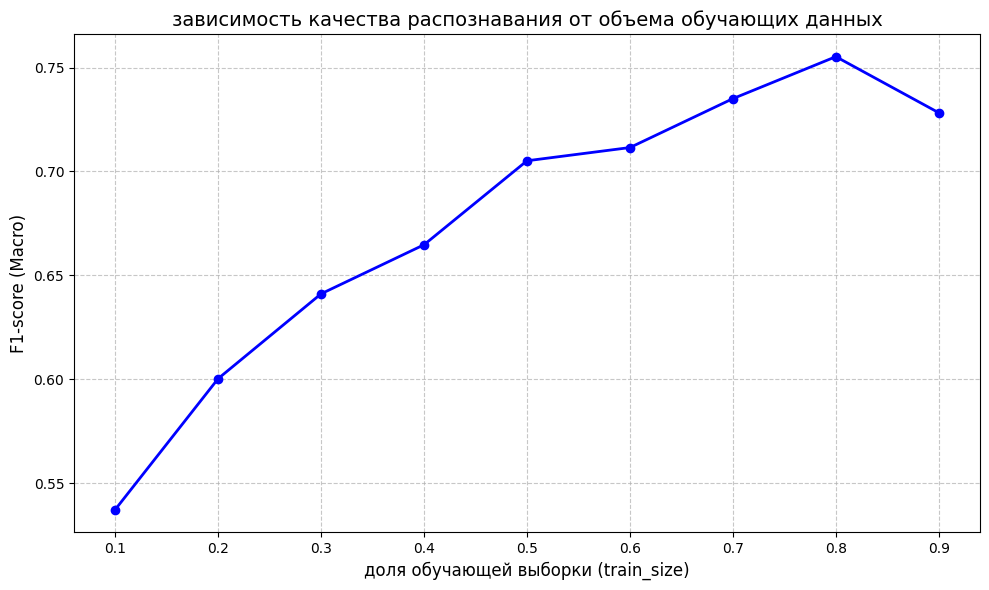

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, f1_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('зависимость качества распознавания от объема обучающих данных', fontsize=14)
plt.xlabel('доля обучающей выборки (train_size)', fontsize=12)
plt.ylabel('F1-score (Macro)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(train_sizes)
plt.tight_layout()
plt.show()